In [ ]:
# ============================================================
# 05 — Feature Engineering
# ============================================================
# Every feature created here is directly justified by a finding from
# the EDA — no feature is added "just in case". See
# src/features/build_features.py for the full business logic behind
# each one, documented in code comments.

import sys
sys.path.append("../")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.features.build_features import fit_feature_stats, apply_feature_engineering

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

train_clean = pd.read_csv("../data/processed/train_clean.csv")
test_clean = pd.read_csv("../data/processed/test_clean.csv")

TARGET = "Churn"

In [2]:
# Split BEFORE fitting feature stats — same leakage discipline as the
# preprocessing pipeline (Step 4). Target-encoded features especially
# MUST be learned only on the training fold.

X = train_clean.drop(columns=[TARGET])
y = train_clean[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Recombine X_train + y_train temporarily, since fit_feature_stats()
# needs the target column to compute target encodings.
train_fit_df = X_train.copy()
train_fit_df[TARGET] = y_train.values

feature_stats = fit_feature_stats(train_fit_df, target_col=TARGET)
print("Feature stats learned from training fold only.")
print("Global churn rate used for smoothing:", round(feature_stats["global_churn_rate"], 4))

Feature stats learned from training fold only.
Global churn rate used for smoothing: 0.1812


In [3]:
# Apply the SAME learned stats to train, validation, and test —
# guarantees consistent feature values across all three sets.

X_train_fe = apply_feature_engineering(X_train, feature_stats)
X_val_fe = apply_feature_engineering(X_val, feature_stats)
test_fe = apply_feature_engineering(test_clean, feature_stats)

new_features = [c for c in X_train_fe.columns if c not in X_train.columns]
print(f"New engineered features ({len(new_features)}):")
print(new_features)

X_train_fe[new_features].head()

New engineered features (13):
['tenure_bucket', 'is_early_lifecycle', 'avg_monthly_spend_historical', 'engagement_score', 'is_low_engagement', 'is_high_value_plan', 'is_high_price_new_customer', 'tickets_per_tenure_month', 'is_high_support_friction', 'SubscriptionType_risk_encoded', 'PaymentMethod_risk_encoded', 'GenrePreference_risk_encoded', 'disengaged_and_high_friction']


,tenure_bucket,is_early_lifecycle,avg_monthly_spend_historical,engagement_score,is_low_engagement,is_high_value_plan,is_high_price_new_customer,tickets_per_tenure_month,is_high_support_friction,SubscriptionType_risk_encoded,PaymentMethod_risk_encoded,GenrePreference_risk_encoded,disengaged_and_high_friction
112198,3-5y,0,18.667225,0.062366,0,1,0,0.074074,0,0.163280,0.161901,0.164709,0
35340,3-5y,0,13.340015,1.251335,0,0,0,0.027027,0,0.163280,0.192429,0.164709,0
33223,5y+,0,11.440717,0.354652,0,0,0,0.038961,0,0.163280,0.161901,0.176451,0
188717,1-2y,0,16.872436,-0.247266,1,1,0,0.307692,0,0.196047,0.191181,0.193108,0
81575,3-5y,0,17.075056,0.055334,0,1,0,0.163636,1,0.163280,0.161901,0.193108,0


C:\Users\houss\AppData\Local\Temp\ipykernel_22180\2625341612.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=validation_df, x=TARGET, y=col, ax=ax, palette=["#55A868", "#C44E52"])
C:\Users\houss\AppData\Local\Temp\ipykernel_22180\2625341612.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=validation_df, x=TARGET, y=col, ax=ax, palette=["#55A868", "#C44E52"])
C:\Users\houss\AppData\Local\Temp\ipykernel_22180\2625341612.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=validation_df, x=TARGET, y=col, ax=ax, palette=[

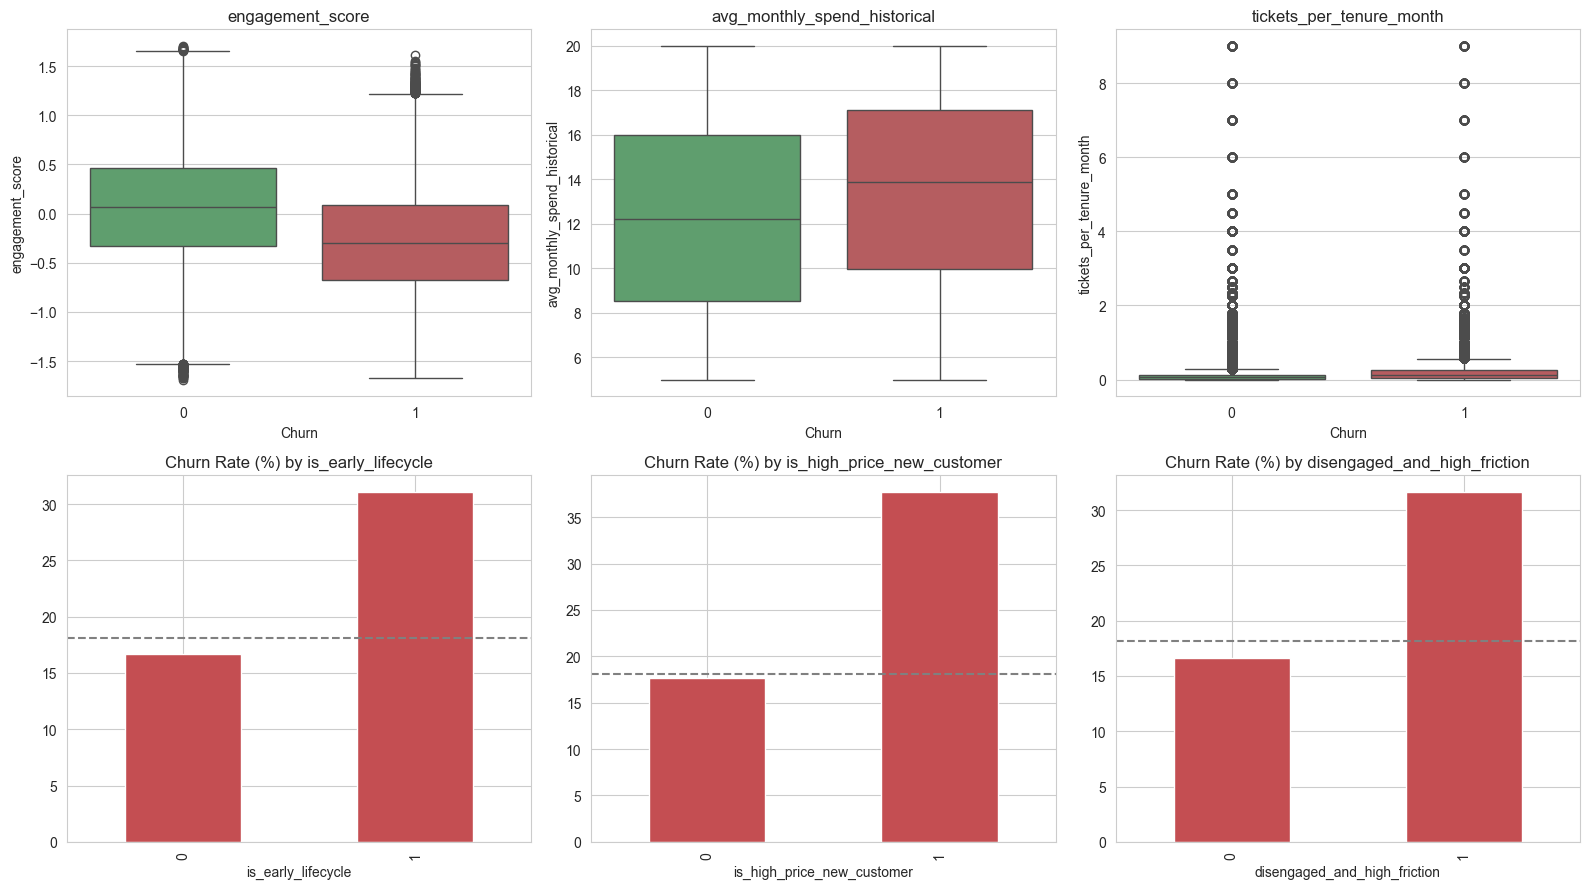

In [4]:
# Re-attach the target temporarily, only for validation plots —
# never used to refit any statistic at this point.
validation_df = X_train_fe.copy()
validation_df[TARGET] = y_train.values

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

numeric_new_features = ["engagement_score", "avg_monthly_spend_historical", "tickets_per_tenure_month"]
for ax, col in zip(axes[:3], numeric_new_features):
    sns.boxplot(data=validation_df, x=TARGET, y=col, ax=ax, palette=["#55A868", "#C44E52"])
    ax.set_title(col)

binary_new_features = ["is_early_lifecycle", "is_high_price_new_customer", "disengaged_and_high_friction"]
for ax, col in zip(axes[3:], binary_new_features):
    rate = validation_df.groupby(col)[TARGET].mean() * 100
    rate.plot(kind="bar", ax=ax, color="#C44E52")
    ax.set_title(f"Churn Rate (%) by {col}")
    ax.axhline(validation_df[TARGET].mean() * 100, color="gray", linestyle="--")

plt.tight_layout()
plt.savefig("../reports/figures/engineered_features_validation.png", dpi=150)
plt.show()

In [5]:
# Correlation of new numeric/binary features with churn — quick ranked
# check of whether the engineering effort actually added signal beyond
# the raw features already available.

all_numeric_new = numeric_new_features + binary_new_features + [
    "SubscriptionType_risk_encoded", "PaymentMethod_risk_encoded", "GenrePreference_risk_encoded"
]

corr_with_target = validation_df[all_numeric_new + [TARGET]].corr()[TARGET].drop(TARGET)
corr_with_target.sort_values(key=abs, ascending=False)

engagement_score                -0.232646
disengaged_and_high_friction     0.116693
is_early_lifecycle               0.111212
tickets_per_tenure_month         0.105933
avg_monthly_spend_historical     0.099698
is_high_price_new_customer       0.080185
SubscriptionType_risk_encoded    0.035116
PaymentMethod_risk_encoded       0.031837
GenrePreference_risk_encoded     0.027036
Name: Churn, dtype: float64

## Engineered Features — Correlation Validation

| Feature | Correlation with Churn | Raw feature baseline (Step 3) | Verdict |
|---|---|---|---|
| `engagement_score` | **-0.233** | ViewingHoursPerWeek -0.13, AverageViewingDuration -0.15, ContentDownloadsPerMonth -0.13 | **Improved** — stronger than any individual raw component, and even slightly stronger than AccountAge (-0.20), the previous top driver |
| `disengaged_and_high_friction` | 0.117 | SupportTicketsPerMonth +0.08 | **Improved** — combining low engagement + high friction produces a stronger signal than support tickets alone |
| `is_early_lifecycle` | 0.111 | AccountAge -0.20 | **Weaker** (expected) — binary bucketing compresses the tenure signal; useful for interpretability, not for raw linear strength |
| `tickets_per_tenure_month` | 0.106 | SupportTicketsPerMonth +0.08 | **Improved** — tenure-normalization adds signal over the raw ticket count |
| `avg_monthly_spend_historical` | 0.100 | TotalCharges -0.12, MonthlyCharges +0.10 | **Redundant, not additive** — see note below |
| `is_high_price_new_customer` | 0.080 | — (interaction feature) | Moderate — weaker than its individual components (`is_early_lifecycle` 0.111), as expected for an AND-interaction with a smaller affected subgroup |
| `SubscriptionType_risk_encoded` | 0.035 | Chi2 = 318.45 (strongest categorical driver) | **Misleading if compared directly** — see note below |
| `PaymentMethod_risk_encoded` | 0.032 | Chi2 = 239.86 | Same caveat as above |
| `GenrePreference_risk_encoded` | 0.027 | Chi2 = 169.30 | Same caveat as above |

**Key interpretations:**

- **`engagement_score` is the clear win of this feature engineering pass**
  — it is now the single strongest numeric predictor in the dataset,
  outperforming even `AccountAge`. This validates the EDA hypothesis that
  the three raw engagement metrics carry a shared underlying signal that
  is diluted when used separately, and confirms it should be a top
  candidate feature for the model (Step 6) and for SHAP analysis (Step 7).
- **`tickets_per_tenure_month` and `disengaged_and_high_friction` both
  improved on their raw counterpart** (`SupportTicketsPerMonth`,
  0.08 → 0.106 and 0.117) — tenure-normalization and combining weak
  signals both worked as intended here, even if modestly.
- **`avg_monthly_spend_historical` did not add real value.** Its
  correlation (0.10) is nearly identical to raw `MonthlyCharges` (0.10),
  not a blend of `MonthlyCharges` and `TotalCharges` as intended. This
  makes sense mathematically: `TotalCharges / AccountAge` converges
  toward the customer's typical monthly charge, so the feature ended up
  behaving like a proxy for `MonthlyCharges` rather than reducing the
  AccountAge/TotalCharges redundancy as planned. **Decision**: keep it
  as a candidate for now (harmless), but don't expect it to outperform
  `MonthlyCharges` in feature importance — the multicollinearity concern
  with `AccountAge`/`TotalCharges` should instead be handled by feature
  selection or regularization at the modeling step, not by this ratio.
- **The target-encoded categorical features show low Pearson correlation
  despite being derived from statistically strong Chi-square relationships
  — this is expected, not a failure.** Pearson correlation measures
  *linear* association and is naturally bounded by the *variance* of the
  feature. Since `SubscriptionType`, `PaymentMethod`, and `GenrePreference`
  only have 3-5 categories with churn rates clustered in a narrow range
  (roughly 16%-19.5%, per the categorical EDA), the encoded values
  themselves have low variance — capping how large any Pearson correlation
  can be, regardless of how meaningful the categorical relationship is.
  **These features should not be judged by Pearson correlation alone.**
  Their real predictive value will be assessed correctly via feature
  importance (tree-based) and SHAP in Step 6/7, which capture non-linear
  and categorical relationships that Pearson correlation cannot.

**Overall conclusion**: the feature engineering pass produced one clear
high-value feature (`engagement_score`), two modest improvements
(`tickets_per_tenure_month`, `disengaged_and_high_friction`), one
redundant feature to monitor but not remove (`avg_monthly_spend_historical`),
and three categorical features whose value cannot be judged from this
correlation table alone and will be re-evaluated with tree-based feature
importance in the modeling step.


In [ ]:
# Compare against the original raw feature correlations as a
# reference point — the goal is for at least some engineered features
# to show a STRONGER correlation than their raw components.

print("Reference — raw feature correlations with churn (from Step 3 EDA):")
print("AccountAge: -0.20 | ViewingHoursPerWeek: -0.13 | AverageViewingDuration: -0.15")
print("MonthlyCharges: +0.10 | SupportTicketsPerMonth: +0.08")
print("\nEngineered feature correlations (above) should be interpreted against these baselines.")

Reference — raw feature correlations with churn (from Step 3 EDA):
AccountAge: -0.20 | ViewingHoursPerWeek: -0.13 | AverageViewingDuration: -0.15
MonthlyCharges: +0.10 | SupportTicketsPerMonth: +0.08

Engineered feature correlations (above) should be interpreted against these baselines.


In [7]:
import os
os.makedirs("../data/processed", exist_ok=True)

# Re-attach targets for the train/val splits before saving, so the
# modeling notebook (Step 6) can load these directly without re-splitting.
X_train_fe[TARGET] = y_train.values
X_val_fe[TARGET] = y_val.values

X_train_fe.to_csv("../data/processed/train_features.csv", index=False)
X_val_fe.to_csv("../data/processed/val_features.csv", index=False)
test_fe.to_csv("../data/processed/test_features.csv", index=False)

# Persist the fitted feature stats too — required to apply identical
# feature engineering to new data in production (Step 10, API).
import joblib
joblib.dump(feature_stats, "../models/feature_engineering_stats.pkl")

print("Saved:")
print("- ../data/processed/train_features.csv")
print("- ../data/processed/val_features.csv")
print("- ../data/processed/test_features.csv")
print("- ../models/feature_engineering_stats.pkl")

Saved:
- ../data/processed/train_features.csv
- ../data/processed/val_features.csv
- ../data/processed/test_features.csv
- ../models/feature_engineering_stats.pkl
